## Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, cross_val_score

# Doğrusal Regresyon (Linear Regression)

🎯 Bu egzersizde, bir NBA oyuncusunun win rating (`win_rating`) performansını, oynadığı dakika (`mp`) gibi maç istatistiklerine göre modelleyeceksiniz.


👉 [NBA.csv](https://d32aokrjazspmn.cloudfront.net/materials/NBA.csv) dataset’ini bu notebook’a bir pandas dataframe olarak yükleyin ve ilk 5 satırını görüntüleyin.

In [24]:
df = pd.read_csv('data/NBA.csv')

df.head()

,season,poss,mp,do_ratio,pacing,win_rating
0,1987,4847,2409,-1.546275,-0.599918,1.643091
1,2017,5582,2708,0.996587,0.531888,10.808427
2,2016,4976,2407,0.242598,0.127976,3.054773
3,2021,1178,585,-1.343806,-1.201034,0.230004
4,1988,4534,2056,-1.813990,-0.128997,0.905614


ℹ️ Dataset’in detaylı açıklamasını challenge README dosyasında bulabilirsiniz. Challenge boyunca buna mutlaka referans verin.


## 1. Özellik Setini ve Hedefi Tanımlayın (Define Feature Set and Target)

🎯 İlk hedef, oyuncuların akranlarına kıyasla genel performans puanı olan *Wins Above Replacement* (`win_rating`) değerini, oynadıkları dakika sayısına (`mp`) göre modellemektir.

👉 Bu iki değişkeni `X` ve `y` olarak atayın. `X`’in feature(lar), `y`’nin ise target olduğunu unutmayın.

In [25]:
X_simple = df[['mp']]
y = df['win_rating']

# Kontrol edelim
print("Özellikler (X) shape:", X.shape)
print("Hedef değişken (y) shape:", y.shape)
print("\nÖzellik kolonları:")
print(X.columns.tolist())


Özellikler (X) shape: (4000, 4)
Hedef değişken (y) shape: (4000,)

Özellik kolonları:
['poss', 'mp', 'do_ratio', 'pacing']


👉 Bir [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) kullanarak rating ile oynanan dakika sayısı arasındaki ilişkiyi görselleştirin.

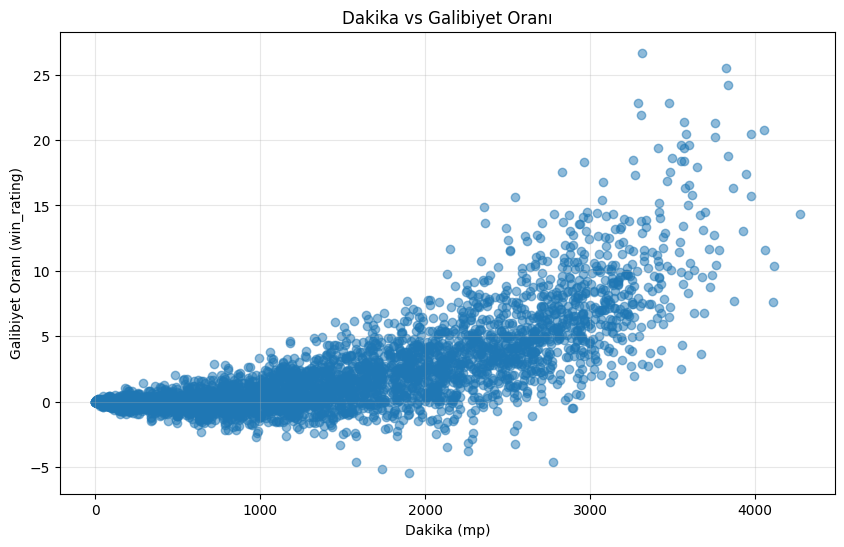

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['mp'], df['win_rating'], alpha=0.5)
plt.xlabel('Dakika (mp)')
plt.ylabel('Galibiyet Oranı (win_rating)')
plt.title('Dakika vs Galibiyet Oranı')
plt.grid(True, alpha=0.3)
plt.show()

ℹ️ Scatter plot, aralarında bir ilişki olduğunu düşündürmeli. Ancak bu ilişki tamamen doğrusal mı? 🤔 Göreceğiz!

## 2. Çapraz Doğrulama (Cross-Validation)

👉 Sklearn’in [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) fonksiyonunu kullanarak, oyuncu performans rating’ini oynanan dakika sayısına göre tahmin eden bir [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) modeli üzerinde 5-fold cross-validation çalıştırın. Cross-validation’ın ham çıktısını `cv_results` adlı yeni bir değişkende saklayın.

In [ ]:
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

cv_results = cross_validate(model, X, y, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)


print("Cross-Validation Sonuçları:")
print(f"Train MSE: {-cv_results['train_score'].mean():.4f}")
print(f"Test MSE: {-cv_results['test_score'].mean():.4f}")
print(f"Test Std: {cv_results['test_score'].std():.4f}")

Cross-Validation Sonuçları:
Train MSE: 4.3544
Test MSE: 4.4188
Test Std: 0.5379


❓ Cross-validation sonuçları içindeki en düşük skor nedir?  
Cevabınızı hesaplayın ve değeri `min_score` adlı yeni bir değişkende saklayın.

In [29]:
min_score = cv_results['test_score'].min()
print(f"En kötü test skoru: {-min_score}")
print(f"En düşük test skoru (pozitif MSE): {-min_score:.4f}")

En kötü test skoru: 5.100906946767813
En düşük test skoru (pozitif MSE): 5.1009


❓ Cross-validation sonuçları içindeki en yüksek skor nedir?  
Cevabınızı hesaplayın ve değeri `max_score` adlı yeni bir değişkende saklayın.

In [30]:
max_score = cv_results['test_score'].max()
print(f"En iyi test skoru: {-max_score}")
print(f"En yüksek test skoru (pozitif MSE): {-max_score:.4f}")

En iyi test skoru: 3.720860404673773
En yüksek test skoru (pozitif MSE): 3.7209


❓ Cross-validation sonuçlarının ortalama skoru nedir?  
Cevabınızı hesaplayın ve değeri `mean_score` adlı yeni bir değişkende saklayın.

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
mean_score = scores.std()  # Standart sapma

print(f"Test skorlarının standart sapması: {mean_score:.4f}")

Test skorlarının standart sapması: 0.5379


ℹ️ Cross-validation çalıştırırken, model performansının en sağlam ve en temsil edici değerlendirmesi olarak her zaman ortalama skora bakarız.

### ☑️ Kodunu Test Et

In [32]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'cv_results',
    cv_result = cv_results,
    mean_score = mean_score
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S16D1-S-data-linear-regression/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 2 items

test_cv_results.py::TestCvResults::test_cv_mean PASSED                   [ 50%]
test_cv_results.py::TestCvResults::test_cv_results PASSED                [100%]

============================== 2 passed in 0.14s ===============================


💯 You can commit your code:

git add tests/cv_results.pickle

git commit -m 'Completed cv_results step'

git push origin master



🤔 **Şimdi K-fold sayısının `K` (yani `cross_validate()` içindeki `cv` parametresi) etkisini inceleyelim**

👉 `K` değeri 2’den 20’ye çıkarken **<u>toplam</u> hesaplama süresinin (fit + score)** ve **<u>ortalama</u> skorun** nasıl değiştiğini plot edin.

<details>
  <summary markdown='span'><strong>İpucu</strong></summary>

  1. `K` değerlerini, hesaplama sürelerini ve cv ortalama skorlarını saklamak için 3 liste oluşturun.
  1. 2’den 20’ye kadar `K` değerleri üzerinde döngü kurun ve her seferinde:
     1. Cross-validation çalıştırın.
     1. `fit_time` ve `score_time` toplamını, toplam süreler listenize ekleyin.
     1. Ortalama `test_score` değerini, cv ortalama skorları listenize ekleyin.
  1. İki adet plot oluşturun:
     1. `K`’ye karşı toplam süre.
     1. `K`’ye karşı ortalama skor.
</details>


In [ ]:
k_values = []
fit_times = []
score_times = []
test_scores = []
for k in range(2, 21):
    model = LinearRegression()
    cv_results = cross_validate(model, X, y, cv=5,
                               scoring='neg_mean_squared_error',
                               return_train_score=True)

    k_values.append(k)
    fit_times.append(cv_results['fit_time'].sum())
    score_times.append(cv_results['score_time'].sum())
    test_scores.append(-cv_results['test_score'].mean())

    print("Dongu Tamamlandi")
    print(f"K degerleri: {k_values}")

Dongu Tamamlandi
K degerleri: [2]
Dongu Tamamlandi
K degerleri: [2, 3]
Dongu Tamamlandi
K degerleri: [2, 3, 4]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Dongu Tamamlandi
K degerleri: [2, 3, 4, 5, 6, 7, 8, 9, 10, 1

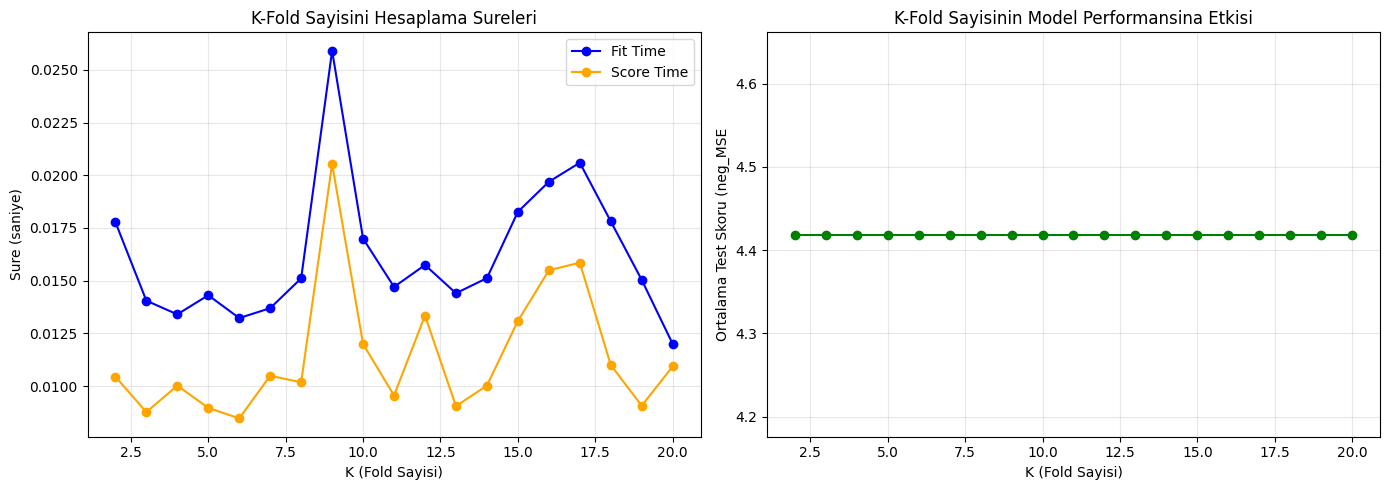

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, fit_times, marker='o', label='Fit Time', color='blue')
axes[0].plot(k_values, score_times, marker='o', label='Score Time', color='orange')
axes[0].set_xlabel('K (Fold Sayisi)')
axes[0].set_ylabel('Sure (saniye)')
axes[0].set_title('K-Fold Sayisini Hesaplama Sureleri')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, test_scores, marker='o', color='green')
axes[1].set_xlabel('K (Fold Sayisi)')
axes[1].set_ylabel('Ortalama Test Skoru (neg_MSE')
axes[1].set_title('K-Fold Sayisinin Model Performansina Etkisi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ℹ️ $R^2$ skorunun sabit kaldığını görmelisiniz; bu, modelin hem daha küçük hem de daha büyük test setlerinde benzer performans gösterdiğinin iyi bir işaretidir. Buna karşılık, hesaplama süresi artmaya devam eder. Bu nedenle, pratik bir kural olarak genellikle K = 10’un üzerine çıkmayız.

## 3. Modeli eğit (Train the Model)

Cross-validation, veri seti üzerinde varsayımsal bir modeli değerlendirmek için kullanılır. Seçtiğiniz fold sayısı kadar modeli birden fazla kez eğitir; her seferinde verinin farklı bir alt kümesi üzerinde eğitilir ve kalan veriyle skor hesaplanır. Bu süreç bize, modelin ne kadar iyi performans gösterebileceğini gösteren cross-validated bir skor verir.

Ancak modeli gerçek anlamda tahmin yapmak için kullanmak istediğinizde, mümkün olduğunca fazla veriyle eğitmeyi tercih edersiniz. Yani verinin bir kısmını ayırmadan.

👉 Modeli, tam `X` ve `y` üzerinde eğitin (model skorunu zaten doğruladık, şimdi tahmin için kullanacağız). Eğitilmiş modeli `model` adlı değişkende saklayın.

In [40]:

X = df[['mp']]  # Sadece mp kolonu
y = df['win_rating']

model = LinearRegression()
model.fit(X, y)

print("Model başarıyla eğitildi! ✅")
print(f"Model katsayıları: {model.coef_}")
print(f"Model intercept: {model.intercept_:.4f}")


Model başarıyla eğitildi! ✅
Model katsayıları: [0.00260258]
Model intercept: -1.5464


❓ Eğitilmiş modelinizin eğimi (slope) ya da katsayısı (coefficient) nedir?  
Bu değere modelin attribute’ları üzerinden erişebilirsiniz. Eğimi `slope` adlı bir değişkende saklayın.

In [41]:
slope = model.coef_[0]
print(f"Model katsayıları (slope): {slope:.4f}")

Model katsayıları (slope): 0.0026


❓ Eğitilmiş modelinizin intercept (sabit terim) değeri nedir?  
Bu değere modelin attribute’ları üzerinden erişebilirsiniz. Intercept değerini `intercept` adlı bir değişkende saklayın.

In [42]:
intercept = model.intercept_
print(f"Model intercept: {intercept:.4f}")

Model intercept: -1.5464


In [43]:
# Hangi kolonlar var bakalım
print("DataFrame kolonları:")
print(df.columns.tolist())
print("\nX kolonları:")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("\nİlk birkaç satır:")
print(df.head())

DataFrame kolonları:
['season', 'poss', 'mp', 'do_ratio', 'pacing', 'win_rating']

X kolonları:
['mp']

X shape: (4000, 1)

İlk birkaç satır:
   season  poss    mp  do_ratio    pacing  win_rating
0    1987  4847  2409 -1.546275 -0.599918    1.643091
1    2017  5582  2708  0.996587  0.531888   10.808427
2    2016  4976  2407  0.242598  0.127976    3.054773
3    2021  1178   585 -1.343806 -1.201034    0.230004
4    1988  4534  2056 -1.813990 -0.128997    0.905614


🤔 Devam etmeden önce bu katsayıları nasıl yorumlayacağınızı anladığınızdan emin olun.

### ☑️ Kodunu Test Et

In [44]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'trained_model',
    slope = slope,
    intercept = intercept
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S16D1-S-data-linear-regression/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 2 items

test_trained_model.py::TestTrainedModel::test_intercept PASSED           [ 50%]
test_trained_model.py::TestTrainedModel::test_slope PASSED               [100%]

============================== 2 passed in 0.17s ===============================


💯 You can commit your code:

git add tests/trained_model.pickle

git commit -m 'Completed trained_model step'

git push origin master



## 4. Tahmin (Predict)

👉 Eğitilmiş modelinizi kullanarak toplamda 1000 dakika oynamış bir oyuncunun performans rating’ini tahmin edin.  
Tahmin edilen değeri `prediction` adlı bir değişkende saklayın.

In [45]:
new_datapoint = pd.DataFrame.from_dict(
    {"mp": [1000]}
)

# Model ile tahmin yapın
prediction = model.predict(new_datapoint)
print(f"1000 dakika için tahmin edilen galibiyet oranı: {prediction[0]:.4f}")

1000 dakika için tahmin edilen galibiyet oranı: 1.0562


### ☑️ Kodunu Test Et

In [47]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction[0]
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S16D1-S-data-linear-regression/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 1 item

test_prediction.py::TestPrediction::test_prediction PASSED               [100%]

============================== 1 passed in 0.15s ===============================


💯 You can commit your code:

git add tests/prediction.pickle

git commit -m 'Completed prediction step'

git push origin master



## 5.  Daha Fazla Özellik ile Modeli İyileştirme (Improving the Model with More Features)

NBA fantasy league’i seven bir arkadaşınız size bazı içgörülerle geliyor 🏀

Bir oyuncunun *Wins Above Replacement* rating’ini değerlendirirken, genellikle topa sahip olma sayısına (`poss`), savunma/hücum oranına (`do_ratio`) ve `pacing` değerine de baktıklarını söylüyor.

❓ Aşağıdaki hücreyi çalıştırarak bu yeni feature’lar ile `win_rating` arasındaki korelasyonu görselleştirin.  
Yukarıdaki feature’lardan **hangisini** modelinize eklemeyi düşünürdünüz?

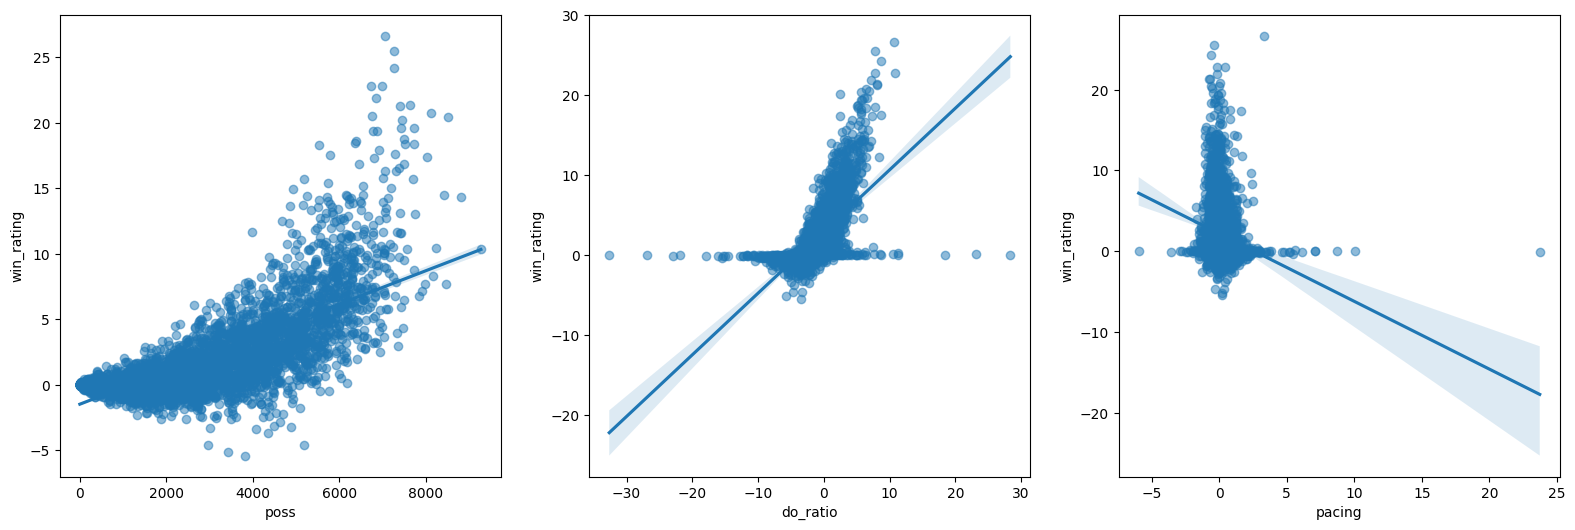

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))

plt.subplots_adjust(left=0.5, right=2)

sns.regplot(data=df, y='win_rating', x='poss', ax=axes[0], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='do_ratio', ax=axes[1], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='pacing', ax=axes[2], scatter_kws={'alpha':0.5})

plt.show()

<details>
  <summary markdown='span'><strong>Cevap</strong></summary>

  Feature’ları manuel olarak seçecek olsaydınız, hedef değişken olan `win_rating` ile en yüksek korelasyona sahip olanlarla başlardınız.

  Regresyon plot’larına baktığımızda, geriye `poss` ve `do_ratio` kalıyor. Sayısal değerleri görmek isterseniz `df.corr()[['win_rating']]` çıktısına bakabilirsiniz.

  Peki neden `poss` değil? Sonuçta `win_rating` ile olan korelasyonu `do_ratio`’dan daha yüksek.

  Bir de şuna bakın: `sns.scatterplot(data=df, x='mp', y='poss');`. Nedenini görebiliyor musunuz?

  <details>
  <summary><strong>Cevap</strong></summary>

  Görünen o ki, ilk feature’ımız olan `mp` ile `poss` neredeyse mükemmele yakın şekilde korelasyonlu. Bu yüzden `poss`, modele çok az ek değer katacaktır.

  </details>

</details>

Şimdi, iki feature kullanan modelin (seçtiğiniz yeni feature ve `mp`) bir oyuncunun rating’ini tahmin etmede ilk modelimizden daha iyi olup olmadığına bakalım.

👉 İki sütunlu bir DataFrame olacak şekilde yeni bir feature set’i oluşturun.

In [57]:
X_improved = df[['mp', 'poss']]
y = df['win_rating']

print("Yeni X shape:", X_improved.shape)
print("Özellikler:", X_improved.columns.tolist())

Yeni X shape: (4000, 2)
Özellikler: ['mp', 'poss']


👉 Şimdi yeni bir linear regression modeli için cross-validation çalıştırın ve **ortalama** skoru `mean_2_feat_score` değişkenine kaydedin.

> Not: Eğer sadece cross-validation skoruyla ilgileniyorsanız (hesaplama süreleriyle değil), sklearn’in [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) fonksiyonunu kullanabilirsiniz.

In [ ]:
model_improved = LinearRegression()

cv_results_improved = cross_validate(model_improved, X_improved, y, cv=5,
                                    scoring='neg_mean_squared_error',
                                    return_train_score=True)

mean_2_feat_score = -cv_results_improved['test_score'].mean()

print(f"2 özellikli model (mp + poss) - mean: {mean_2_feat_score:.4f}")

2 özellikli model (mp + poss) - std: 5.3174


### ☑️ Kodunu Test Et

In [62]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'improved_score',
    improved_score = mean_2_feat_score
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S16D1-S-data-linear-regression/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 1 item

test_improved_score.py::TestImprovedScore::test_improved_score PASSED    [100%]

============================== 1 passed in 0.14s ===============================


💯 You can commit your code:

git add tests/improved_score.pickle

git commit -m 'Completed improved_score step'

git push origin master



$R^2$ değerinizde **yaklaşık %8’lik bir artış** görmelisiniz 👏

Tebrikler, ilk manuel *feature selection* işleminizi gerçekleştirdiniz — bu hafta bunun daha birçok yolunu göreceğiz!

🤔 Peki Linear Regression ile yapabileceğimiz en iyi şey bu mu? Bir sonraki challenge’da bunu daha derinlemesine keşfedelim!

# 🏁